# LeetCode #209: Minimum Size Subarray Sum

https://leetcode.com/problems/minimum-size-subarray-sum/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force** | $O(n^2)$ | $O(1)$ |
| **Binary Search + Prefix Sum** | $O(n \log n)$ | $O(n)$ |
| **Optimal: Sliding Window** | $O(n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force
Try all subarrays by nested loops, compute sum, track the minimum length with sum >= target. This is $O(n^2)$.

### Binary Search + Prefix Sum
Build a prefix sum array. For each start index, binary search for the smallest end index where `prefix[end] - prefix[start] >= target`. Since all values are positive, the prefix sum is monotonically increasing. This gives $O(n \log n)$.

### Optimal: Sliding Window ★
Use two pointers (`left`, `right`) maintaining a window sum.
1. Expand `right`, adding `nums[right]` to the sum.
2. While `sum >= target`, update the minimum length and shrink from `left`.
3. Return the minimum length found, or 0 if no valid subarray exists.

**Why this works:** All elements are positive, so expanding the window increases the sum and shrinking decreases it. Each element is added and removed at most once, giving $O(n)$ total.

**Constraints:**
* `1 <= target <= 10^9`
* `1 <= nums.length <= 10^5`
* `1 <= nums[i] <= 10^4`

## Solutions

### C#

In [ ]:
public class Solution {
    public int MinSubArrayLen(int target, int[] nums) {
        int left = 0, sum = 0;
        int minLen = int.MaxValue;
        
        for (int right = 0; right < nums.Length; right++) {
            sum += nums[right];
            while (sum >= target) {
                minLen = Math.Min(minLen, right - left + 1);
                sum -= nums[left++];
            }
        }
        
        return minLen == int.MaxValue ? 0 : minLen;
    }
}

### Python

In [ ]:
class Solution:
    def minSubArrayLen(self, target: int, nums: list[int]) -> int:
        left = 0
        total = 0
        min_len = float('inf')
        
        for right in range(len(nums)):
            total += nums[right]
            while total >= target:
                min_len = min(min_len, right - left + 1)
                total -= nums[left]
                left += 1
        
        return 0 if min_len == float('inf') else min_len

### Go

In [ ]:
func minSubArrayLen(target int, nums []int) int {
    left, sum := 0, 0
    minLen := len(nums) + 1
    
    for right := 0; right < len(nums); right++ {
        sum += nums[right]
        for sum >= target {
            if right-left+1 < minLen {
                minLen = right - left + 1
            }
            sum -= nums[left]
            left++
        }
    }
    
    if minLen > len(nums) {
        return 0
    }
    return minLen
}

### Rust

In [ ]:
impl Solution {
    pub fn min_sub_array_len(target: i32, nums: Vec<i32>) -> i32 {
        let mut left = 0;
        let mut sum = 0;
        let mut min_len = usize::MAX;
        
        for right in 0..nums.len() {
            sum += nums[right];
            while sum >= target {
                min_len = min_len.min(right - left + 1);
                sum -= nums[left];
                left += 1;
            }
        }
        
        if min_len == usize::MAX { 0 } else { min_len as i32 }
    }
}

## Example Scenarios

1. **Common Case:** `target = 7`, `nums = [2,3,1,2,4,3]` → **2**. Expand right pointer until sum $\geq 7$, then shrink from left. Window $[4,3]$ has sum 7 and length 2. Multiple valid windows exist ($[2,3,1,2,4]$, $[4,3]$, etc.) — sliding window finds the minimum by shrinking aggressively. WHY tricky: Each element is added (right++) and removed (left++) at most once, giving $O(n)$ total despite the nested while loop.

2. **Slightly Complex — Single Element Sufficient:** `target = 4`, `nums = [1,4,4]` → **1**. At index 1, sum $= 5 \geq 4$, window $[1,4]$ length 2. Shrink: remove 1, sum $= 4 \geq 4$, window $[4]$ length 1. Continue: sum $= 0 < 4$, stop. WHY tricky: The inner while loop must continue shrinking even after finding a valid window — it might reach length 1. This is why we use `while`, not `if`.

3. **Edge Case — Time Factor (All Small Values):** `target = 100000`, `nums = [1,1,...,1]` ($10^5$ ones) → **100,000**. Window must grow to include all elements before sum $\geq$ target. Right moves $10^5$ times, left moves once. Total pointer moves $= n + 1 = O(n)$. WHY tricky: Worst case for expansion. Confirms amortized $O(n)$: right pointer moves $n$ times, left $\leq n$ times, total $\leq 2n$.

4. **Edge Case — Space Factor (No Valid Subarray):** `target = 11`, `nums = [1,1,1,1,1,1,1,1]` → **0**. Total sum $= 8 < 11$. Right pointer traverses entirely; left never moves. `minLen` stays at $\infty$, return 0. $S(n) = O(1)$: only 3 variables (left, sum, minLen). WHY tricky: Must correctly return 0 when no valid subarray exists (total sum $<$ target). The sentinel value (infinity) must be distinguishable from valid lengths.

5. **Almost-Impossible — Maximum Constraints:** `target = 10^9`, `nums = [10000,...,10000]` ($10^5$ elements, each $10^4$) → **100,000**. Total sum $= 10^5 \times 10^4 = 10^9 =$ target. The entire array is the only valid subarray. Sum variable reaches $10^9$, which fits in int32 ($\max = 2.1 \times 10^9$) but with little headroom. WHY tricky: Using int64 is safer. The $O(n)$ sliding window handles $10^5$ elements easily; brute force $O(n^2)$ would need $10^{10}$ operations.

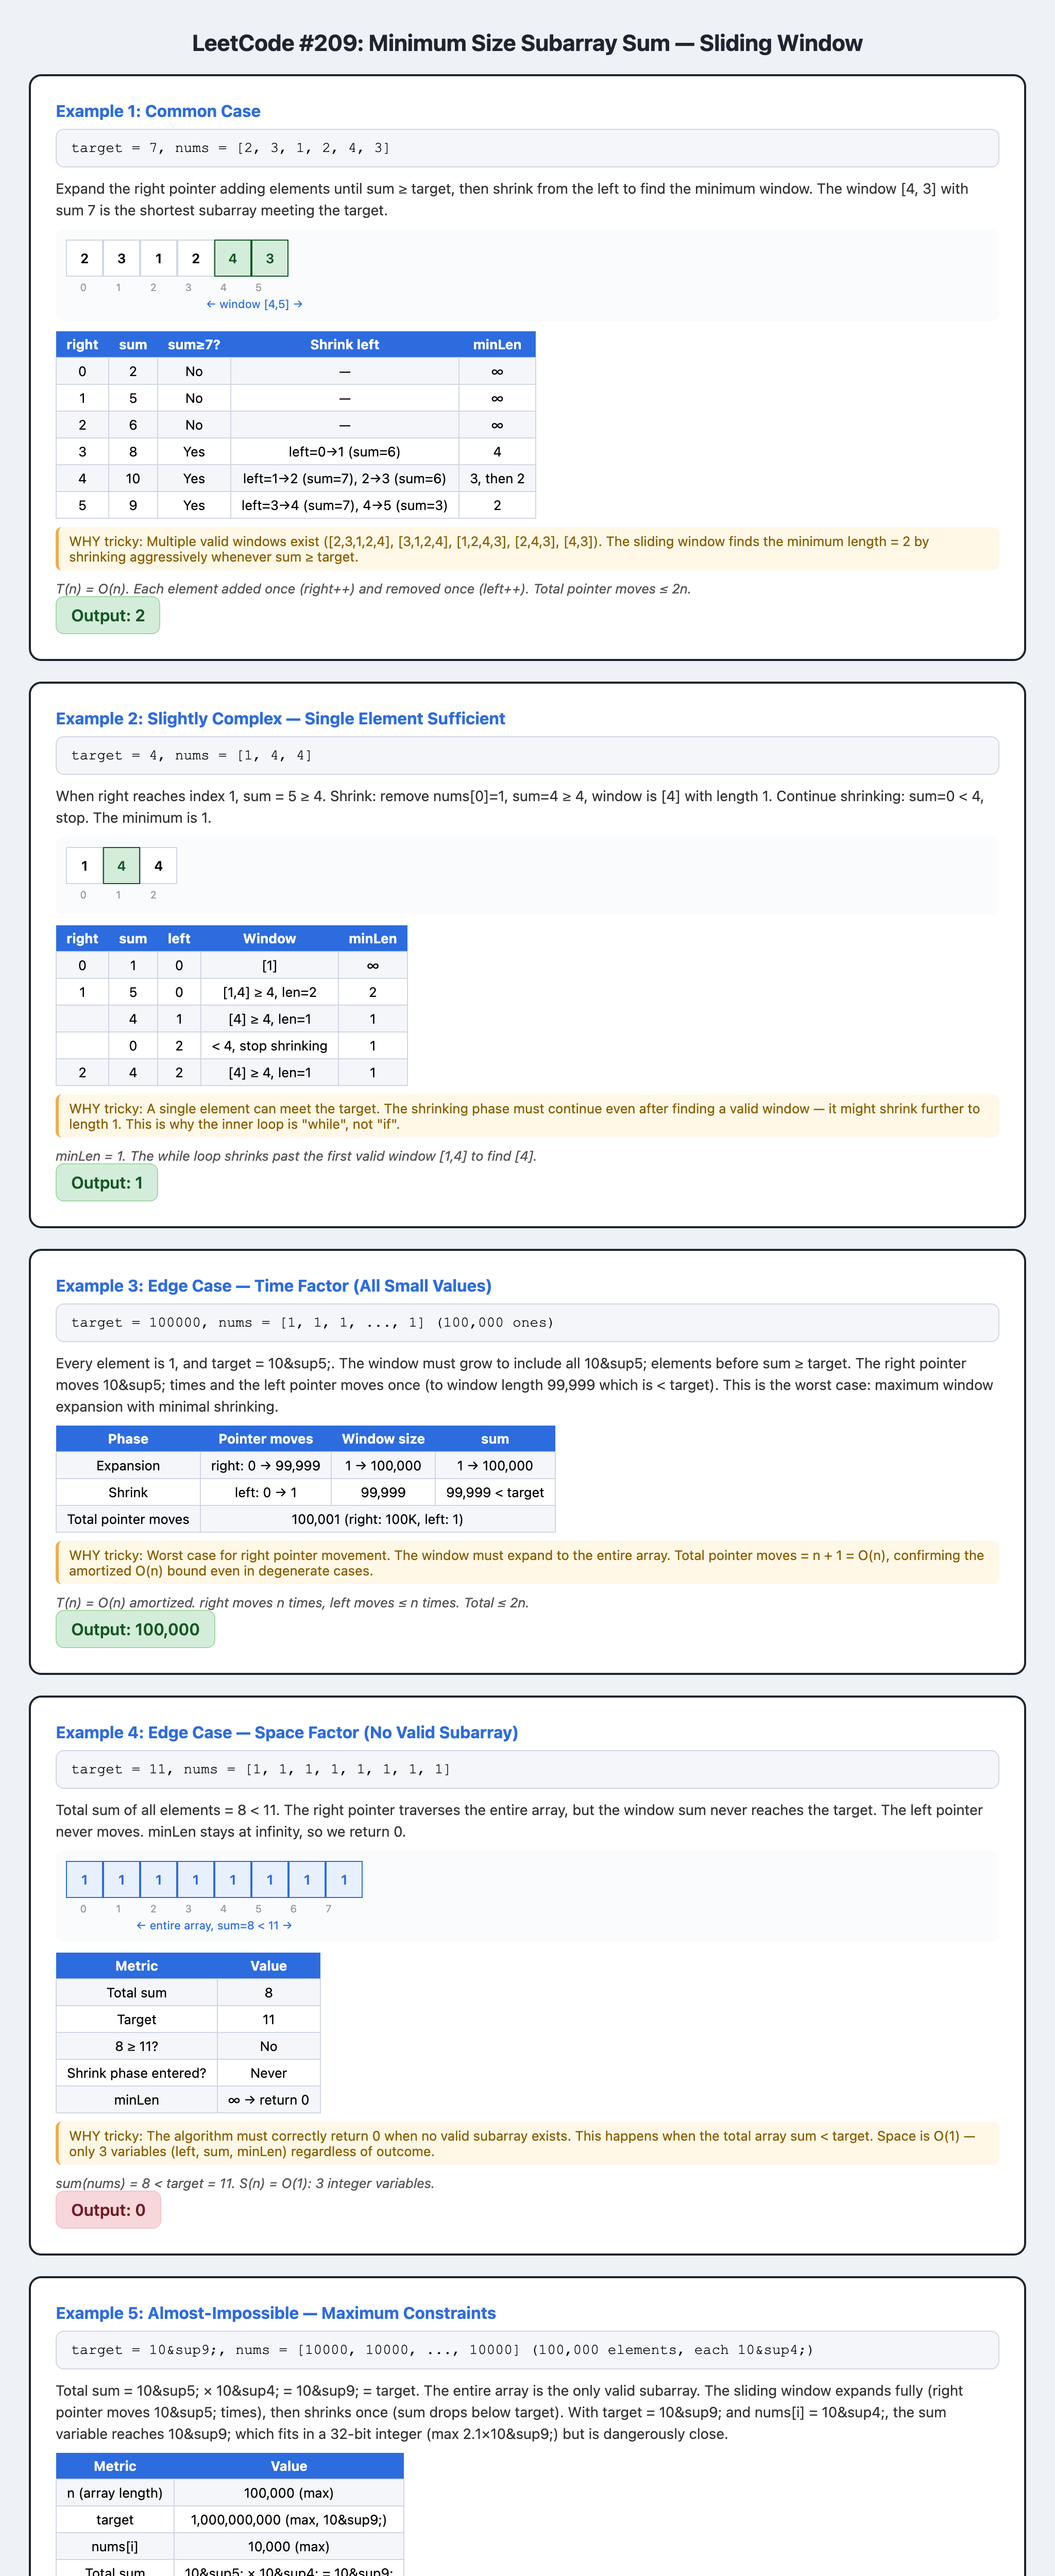